In [1]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [2]:
df=pd.read_csv(r"C:\Users\lenovo\OneDrive\Desktop\data science\sample data\diabetes_risk_prediction_dataset.csv")

In [3]:
df.head()

,Patient_ID,Age,Gender,Country,Height_cm,Weight_kg,BMI,Waist_Circumference_cm,Blood_Glucose,HbA1c,...,PCOS,Medication_Adherence,Work_Type,Residence_Type,Daily_Water_Intake_L,Diabetes_Risk_Score,AI_Health_Recommendation,Doctor_Consultation_Needed,Diabetes_Risk,BMI_CATEGORY
0,1,32.0,Male,Mexico,182.1,65.8,19.8,71.2,88.4,10.4,...,No,Good,Retired,Rural,4.4,60,Healthy Diet Plan,Yes,Moderate,Normal
1,2,42.0,Other,Saudi Arabia,148.5,101.2,45.9,121.8,247.3,11.3,...,Yes,Average,Government,Rural,2.1,99,Begin Diabetes Management Plan,Yes,High,Obese
2,3,89.0,Other,Argentina,158.1,NaN,37.9,131.8,141.9,6.3,...,No,Average,Government,Urban,2.8,80,Strict Blood Sugar Monitoring,Yes,High,Obese
3,4,87.0,Other,United States,190.9,95.9,26.3,99.1,90.1,7.4,...,No,Average,Business,Rural,1.5,82,Begin Diabetes Management Plan,Yes,High,Overweight
4,5,27.0,Other,Australia,156.9,101.9,41.4,77.1,93.8,12.0,...,Yes,Poor,Private,Rural,1.6,93,Begin Diabetes Management Plan,Yes,High,Obese


In [4]:
df.dtypes

Patient_ID                      int64
Age                           float64
Gender                         object
Country                        object
Height_cm                     float64
Weight_kg                     float64
BMI                           float64
Waist_Circumference_cm        float64
Blood_Glucose                 float64
HbA1c                         float64
Fasting_Blood_Sugar           float64
Insulin_Level                 float64
Blood_Pressure_Systolic         int64
Blood_Pressure_Diastolic        int64
Total_Cholesterol             float64
HDL                           float64
LDL                           float64
Triglycerides                 float64
Heart_Rate                      int64
Physical_Activity_Level        object
Exercise_Hours_Per_Week       float64
Daily_Walking_Minutes         float64
Diet_Quality                   object
Sugar_Intake_Level             object
Sleep_Hours                   float64
Stress_Level                   object
Smoking_Stat

In [5]:
important_features=[
    'Age', 
    'Gender', 
    'BMI', 
    'Waist_Circumference_cm', 
    'Blood_Glucose', 
    'HbA1c',
    'Fasting_Blood_Sugar',
    'Insulin_Level',
    'Blood_Pressure_Systolic',
    'Blood_Pressure_Diastolic',
    'Total_Cholesterol',
    'HDL',
    'LDL',
    'Triglycerides',
    'Physical_Activity_Level',
    'Exercise_Hours_Per_Week',
    'Daily_Walking_Minutes',
    'Diet_Quality',
    'Sugar_Intake_Level',
    'Sleep_Hours',
    'Stress_Level',
    'Smoking_Status',
    'Alcohol_Consumption',
    'Family_History_Diabetes',
    'Hypertension',
    'Heart_Disease',
    'Fatty_Liver',
    'PCOS',
    'Work_Type',
    'Residence_Type',
    'Daily_Water_Intake_L'
]
target='Diabetes_Risk'

df=df[important_features+[target]]


In [6]:
df.shape

(50000, 32)

In [7]:
df.columns

Index(['Age', 'Gender', 'BMI', 'Waist_Circumference_cm', 'Blood_Glucose',
       'HbA1c', 'Fasting_Blood_Sugar', 'Insulin_Level',
       'Blood_Pressure_Systolic', 'Blood_Pressure_Diastolic',
       'Total_Cholesterol', 'HDL', 'LDL', 'Triglycerides',
       'Physical_Activity_Level', 'Exercise_Hours_Per_Week',
       'Daily_Walking_Minutes', 'Diet_Quality', 'Sugar_Intake_Level',
       'Sleep_Hours', 'Stress_Level', 'Smoking_Status', 'Alcohol_Consumption',
       'Family_History_Diabetes', 'Hypertension', 'Heart_Disease',
       'Fatty_Liver', 'PCOS', 'Work_Type', 'Residence_Type',
       'Daily_Water_Intake_L', 'Diabetes_Risk'],
      dtype='object')

In [8]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 32 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Age                       49503 non-null  float64
 1   Gender                    50000 non-null  object 
 2   BMI                       50000 non-null  float64
 3   Waist_Circumference_cm    50000 non-null  float64
 4   Blood_Glucose             49041 non-null  float64
 5   HbA1c                     48026 non-null  float64
 6   Fasting_Blood_Sugar       50000 non-null  float64
 7   Insulin_Level             50000 non-null  float64
 8   Blood_Pressure_Systolic   50000 non-null  int64  
 9   Blood_Pressure_Diastolic  50000 non-null  int64  
 10  Total_Cholesterol         49000 non-null  float64
 11  HDL                       49000 non-null  float64
 12  LDL                       49000 non-null  float64
 13  Triglycerides             49000 non-null  float64
 14  Physic

In [9]:
df.isnull().sum()

Age                          497
Gender                         0
BMI                            0
Waist_Circumference_cm         0
Blood_Glucose                959
HbA1c                       1974
Fasting_Blood_Sugar            0
Insulin_Level                  0
Blood_Pressure_Systolic        0
Blood_Pressure_Diastolic       0
Total_Cholesterol           1000
HDL                         1000
LDL                         1000
Triglycerides               1000
Physical_Activity_Level      500
Exercise_Hours_Per_Week     1992
Daily_Walking_Minutes       1964
Diet_Quality                   0
Sugar_Intake_Level             0
Sleep_Hours                 2017
Stress_Level                   0
Smoking_Status                 0
Alcohol_Consumption            0
Family_History_Diabetes        0
Hypertension                   0
Heart_Disease                  0
Fatty_Liver                    0
PCOS                           0
Work_Type                      0
Residence_Type                 0
Daily_Wate

In [10]:
df.duplicated().sum()

np.int64(0)

In [11]:
df['Age']=df['Age'].fillna(df['Age'].mean())

In [12]:
df.isnull().sum()

Age                            0
Gender                         0
BMI                            0
Waist_Circumference_cm         0
Blood_Glucose                959
HbA1c                       1974
Fasting_Blood_Sugar            0
Insulin_Level                  0
Blood_Pressure_Systolic        0
Blood_Pressure_Diastolic       0
Total_Cholesterol           1000
HDL                         1000
LDL                         1000
Triglycerides               1000
Physical_Activity_Level      500
Exercise_Hours_Per_Week     1992
Daily_Walking_Minutes       1964
Diet_Quality                   0
Sugar_Intake_Level             0
Sleep_Hours                 2017
Stress_Level                   0
Smoking_Status                 0
Alcohol_Consumption            0
Family_History_Diabetes        0
Hypertension                   0
Heart_Disease                  0
Fatty_Liver                    0
PCOS                           0
Work_Type                      0
Residence_Type                 0
Daily_Wate

In [13]:
df.dtypes

Age                         float64
Gender                       object
BMI                         float64
Waist_Circumference_cm      float64
Blood_Glucose               float64
HbA1c                       float64
Fasting_Blood_Sugar         float64
Insulin_Level               float64
Blood_Pressure_Systolic       int64
Blood_Pressure_Diastolic      int64
Total_Cholesterol           float64
HDL                         float64
LDL                         float64
Triglycerides               float64
Physical_Activity_Level      object
Exercise_Hours_Per_Week     float64
Daily_Walking_Minutes       float64
Diet_Quality                 object
Sugar_Intake_Level           object
Sleep_Hours                 float64
Stress_Level                 object
Smoking_Status               object
Alcohol_Consumption          object
Family_History_Diabetes      object
Hypertension                 object
Heart_Disease                object
Fatty_Liver                  object
PCOS                        

In [14]:
num_cols=[
    'Blood_Glucose',
    'HbA1c',
    'Total_Cholesterol',
    'HDL',
    'LDL',
    'Triglycerides' ,
    'Exercise_Hours_Per_Week',
    'Daily_Walking_Minutes',
    'Sleep_Hours'
]
for col in num_cols:
    df[col]=df[col].fillna(df[col].median())

In [15]:
df.isnull().sum()

Age                           0
Gender                        0
BMI                           0
Waist_Circumference_cm        0
Blood_Glucose                 0
HbA1c                         0
Fasting_Blood_Sugar           0
Insulin_Level                 0
Blood_Pressure_Systolic       0
Blood_Pressure_Diastolic      0
Total_Cholesterol             0
HDL                           0
LDL                           0
Triglycerides                 0
Physical_Activity_Level     500
Exercise_Hours_Per_Week       0
Daily_Walking_Minutes         0
Diet_Quality                  0
Sugar_Intake_Level            0
Sleep_Hours                   0
Stress_Level                  0
Smoking_Status                0
Alcohol_Consumption           0
Family_History_Diabetes       0
Hypertension                  0
Heart_Disease                 0
Fatty_Liver                   0
PCOS                          0
Work_Type                     0
Residence_Type                0
Daily_Water_Intake_L          0
Diabetes

In [16]:
df['Physical_Activity_Level'] = df['Physical_Activity_Level'].fillna(
    df['Physical_Activity_Level'].mode()[0]
)

In [17]:
df.isnull().sum()

Age                         0
Gender                      0
BMI                         0
Waist_Circumference_cm      0
Blood_Glucose               0
HbA1c                       0
Fasting_Blood_Sugar         0
Insulin_Level               0
Blood_Pressure_Systolic     0
Blood_Pressure_Diastolic    0
Total_Cholesterol           0
HDL                         0
LDL                         0
Triglycerides               0
Physical_Activity_Level     0
Exercise_Hours_Per_Week     0
Daily_Walking_Minutes       0
Diet_Quality                0
Sugar_Intake_Level          0
Sleep_Hours                 0
Stress_Level                0
Smoking_Status              0
Alcohol_Consumption         0
Family_History_Diabetes     0
Hypertension                0
Heart_Disease               0
Fatty_Liver                 0
PCOS                        0
Work_Type                   0
Residence_Type              0
Daily_Water_Intake_L        0
Diabetes_Risk               0
dtype: int64

In [18]:
df.isnull().sum()

Age                         0
Gender                      0
BMI                         0
Waist_Circumference_cm      0
Blood_Glucose               0
HbA1c                       0
Fasting_Blood_Sugar         0
Insulin_Level               0
Blood_Pressure_Systolic     0
Blood_Pressure_Diastolic    0
Total_Cholesterol           0
HDL                         0
LDL                         0
Triglycerides               0
Physical_Activity_Level     0
Exercise_Hours_Per_Week     0
Daily_Walking_Minutes       0
Diet_Quality                0
Sugar_Intake_Level          0
Sleep_Hours                 0
Stress_Level                0
Smoking_Status              0
Alcohol_Consumption         0
Family_History_Diabetes     0
Hypertension                0
Heart_Disease               0
Fatty_Liver                 0
PCOS                        0
Work_Type                   0
Residence_Type              0
Daily_Water_Intake_L        0
Diabetes_Risk               0
dtype: int64

In [19]:
df.describe

<bound method NDFrame.describe of         Age  Gender   BMI  Waist_Circumference_cm  Blood_Glucose  HbA1c  \
0      32.0    Male  19.8                    71.2           88.4   10.4   
1      42.0   Other  45.9                   121.8          247.3   11.3   
2      89.0   Other  37.9                   131.8          141.9    6.3   
3      87.0   Other  26.3                    99.1           90.1    7.4   
4      27.0   Other  41.4                    77.1           93.8   12.0   
...     ...     ...   ...                     ...            ...    ...   
49995  52.0  Female  45.3                    75.9          248.8    9.9   
49996  53.0    Male  19.8                   114.5          198.4    6.3   
49997  88.0    Male  17.4                    96.1          118.8    8.5   
49998  23.0   Other  26.2                   131.4          139.5    9.2   
49999  24.0  Female  40.5                    66.1          123.5    6.8   

       Fasting_Blood_Sugar  Insulin_Level  Blood_Pressure_Systoli

<Axes: xlabel='Gender', ylabel='count'>

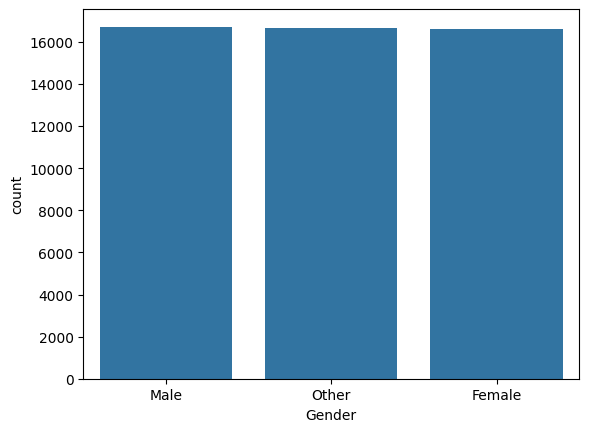

In [20]:
sns.countplot(x=df['Gender'])

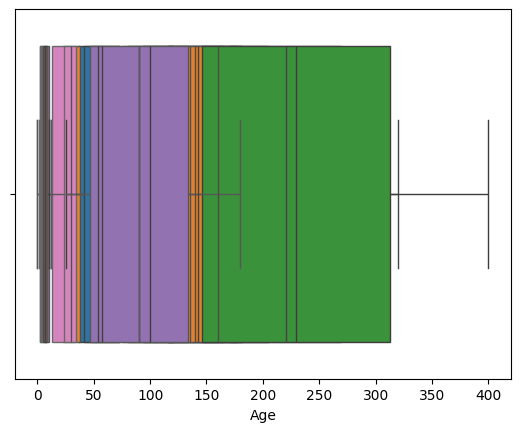

In [21]:
numerical_cols=df.select_dtypes(
    include=np.number
).columns
for col in numerical_cols:
    sns.boxplot(x=df[col])

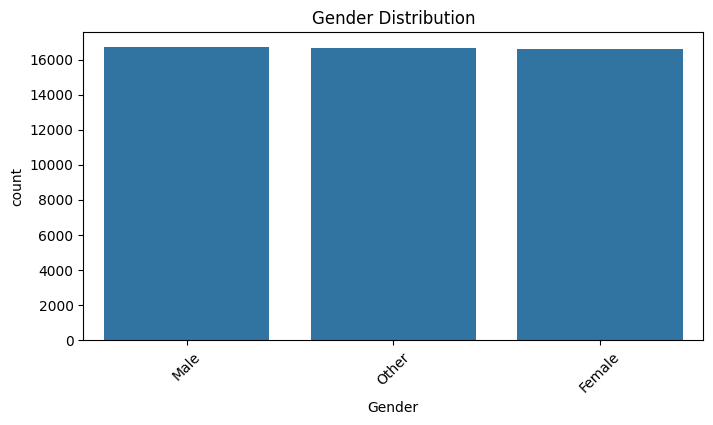

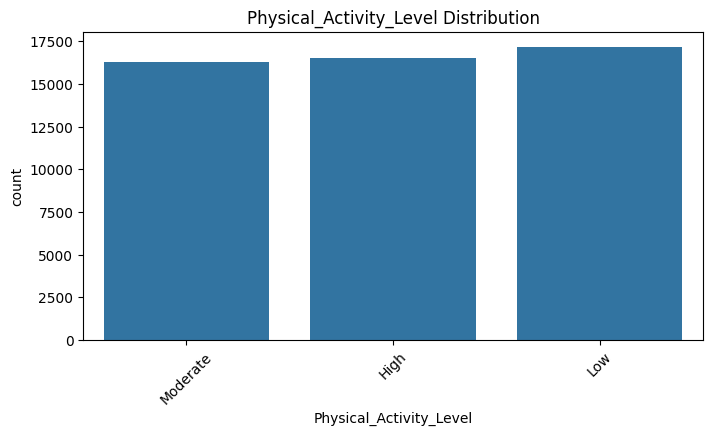

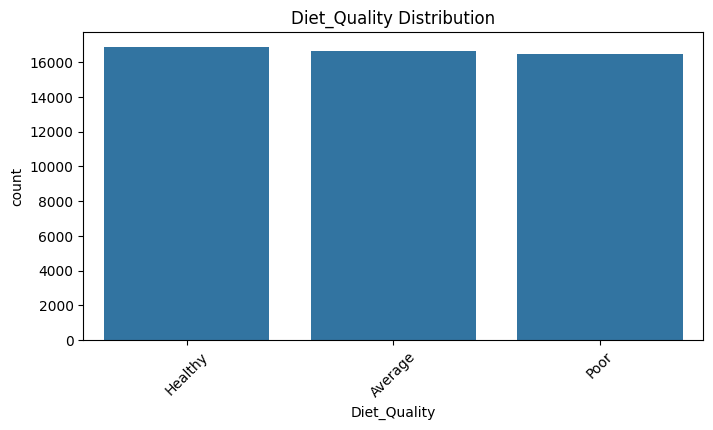

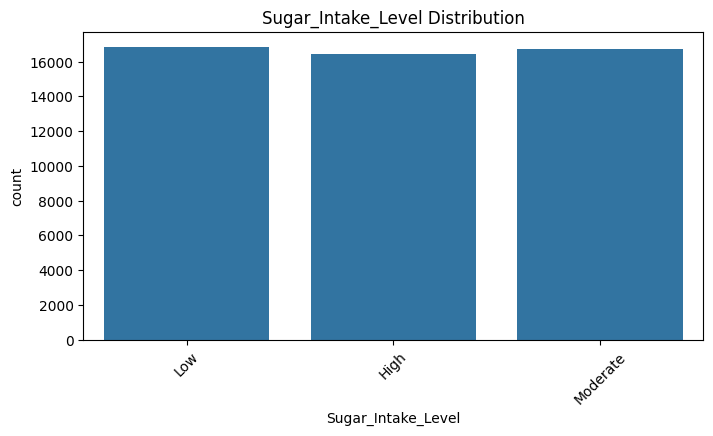

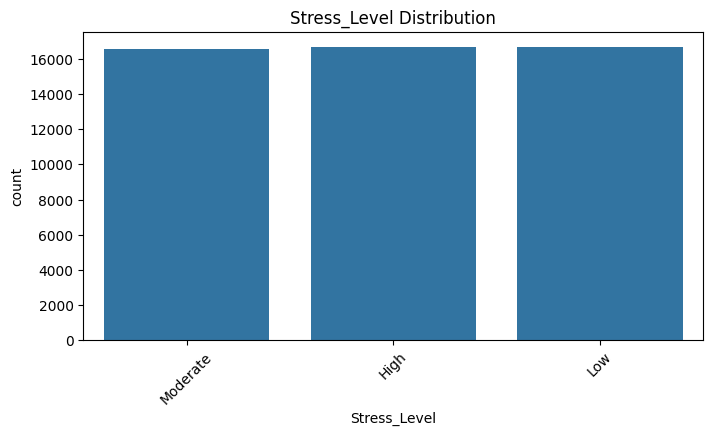

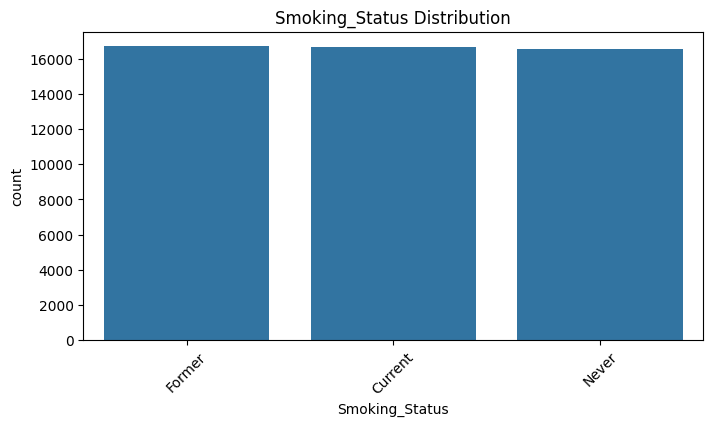

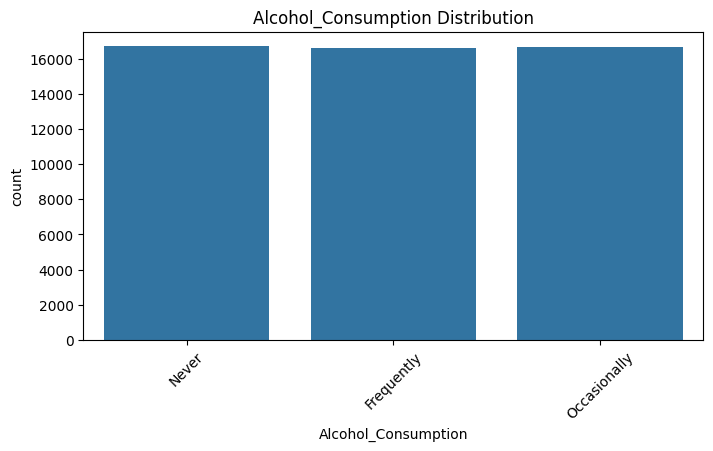

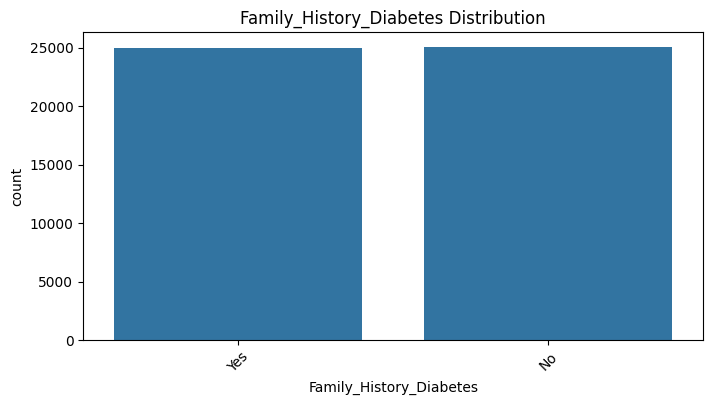

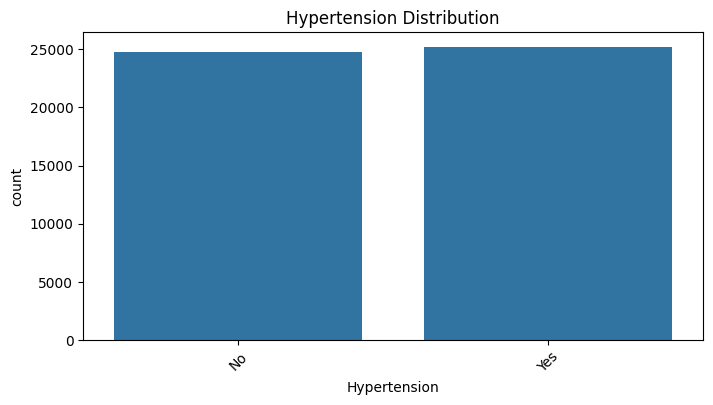

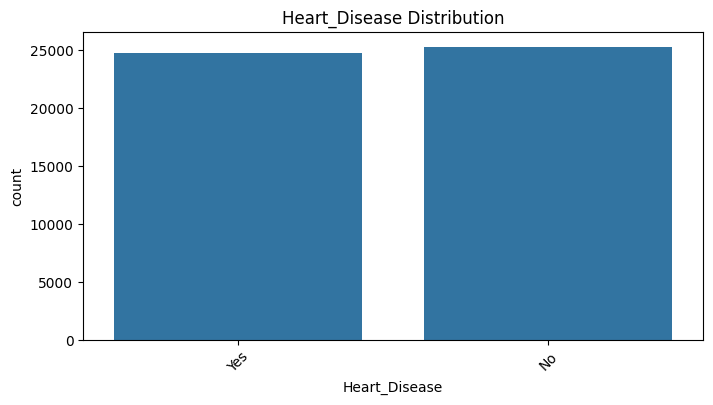

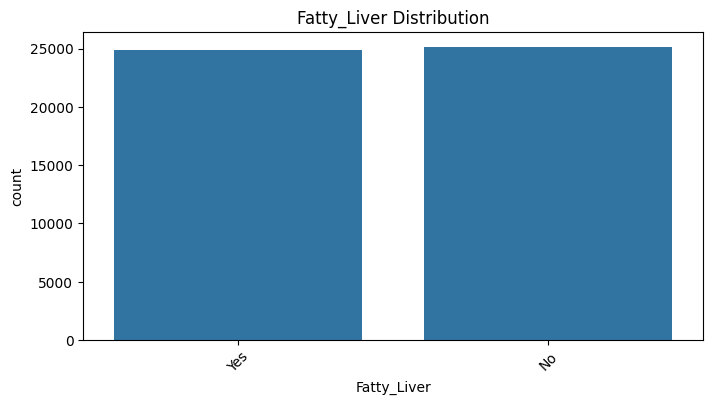

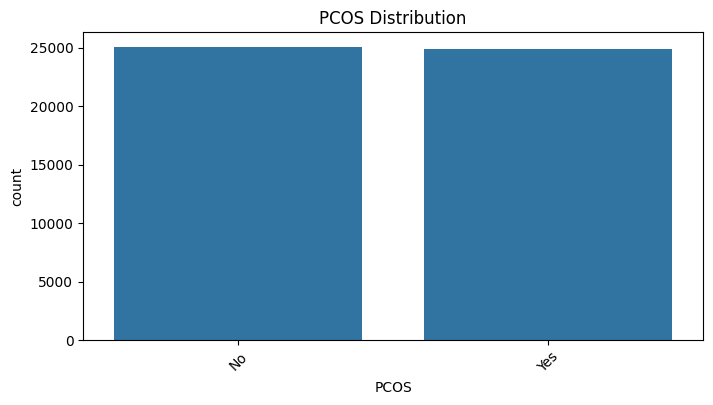

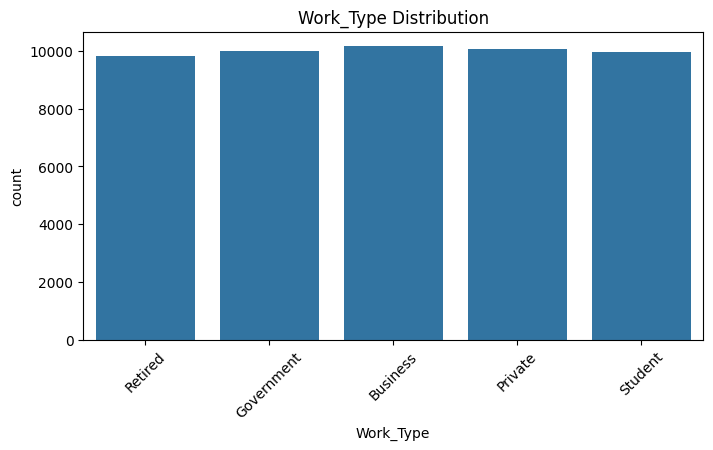

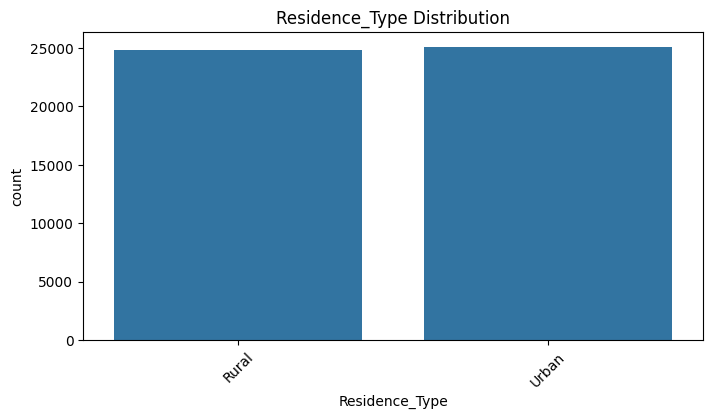

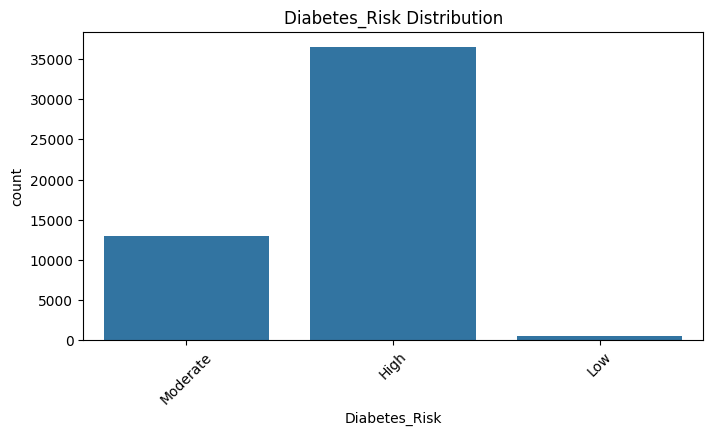

In [22]:
import seaborn as sns
import matplotlib.pyplot as plt

categorical_cols = df.select_dtypes(include='object').columns

for col in categorical_cols:
    plt.figure(figsize=(8, 4))
    sns.countplot(x=df[col])
    plt.title(f'{col} Distribution')
    plt.xticks(rotation=45)
    plt.show()

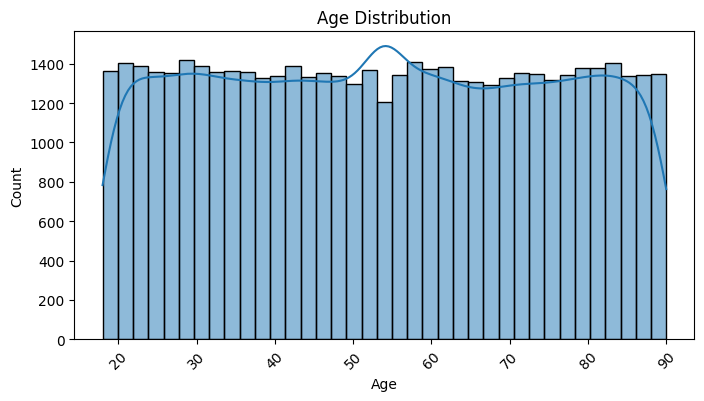

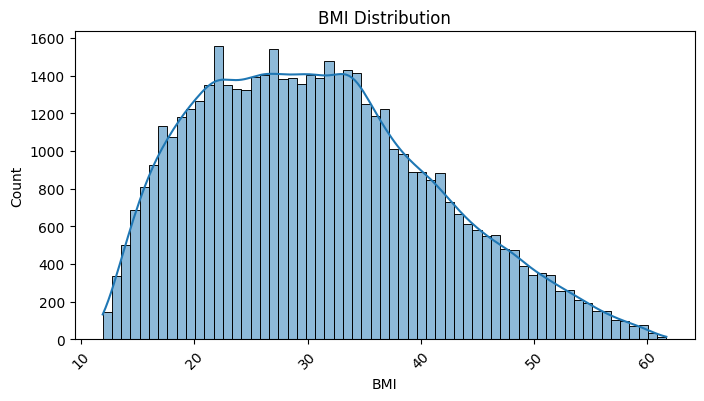

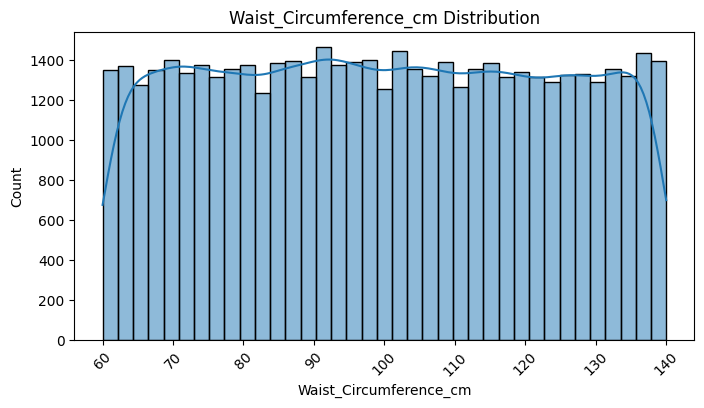

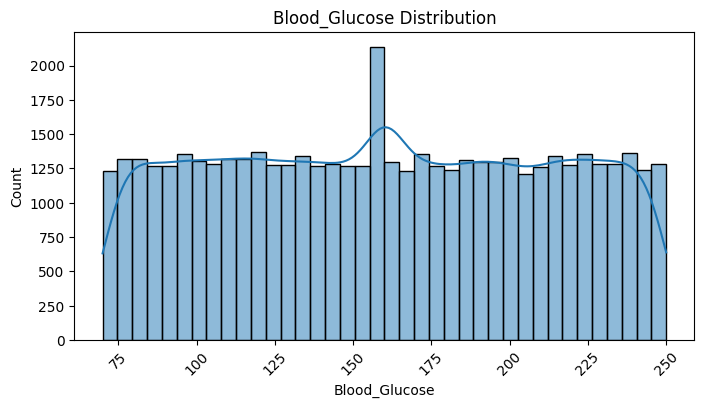

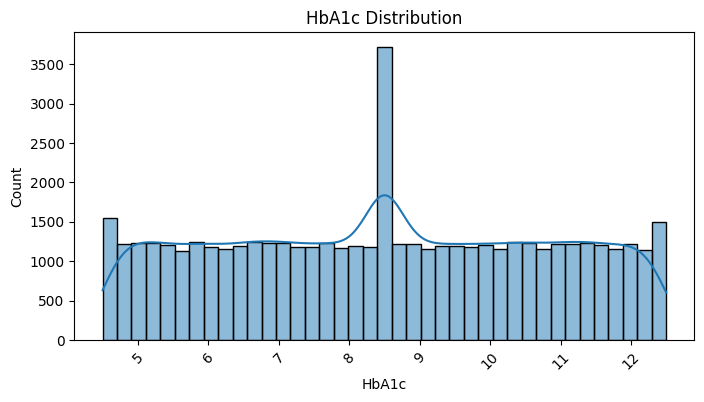

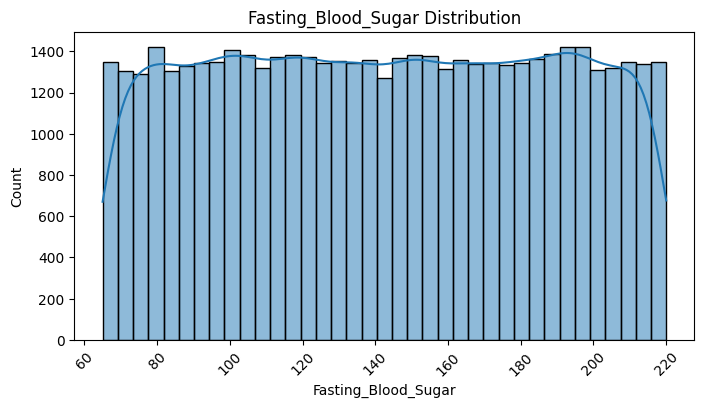

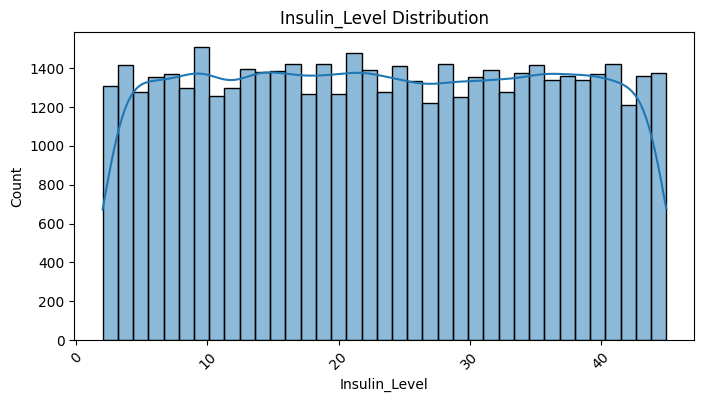

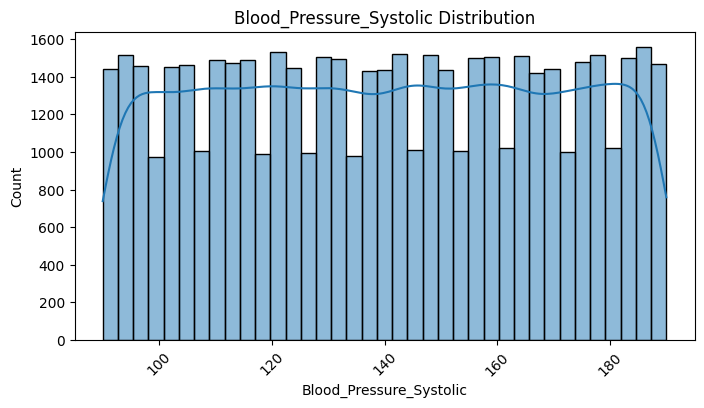

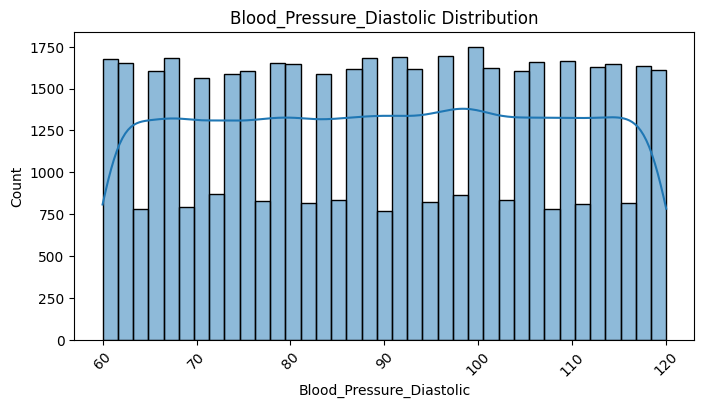

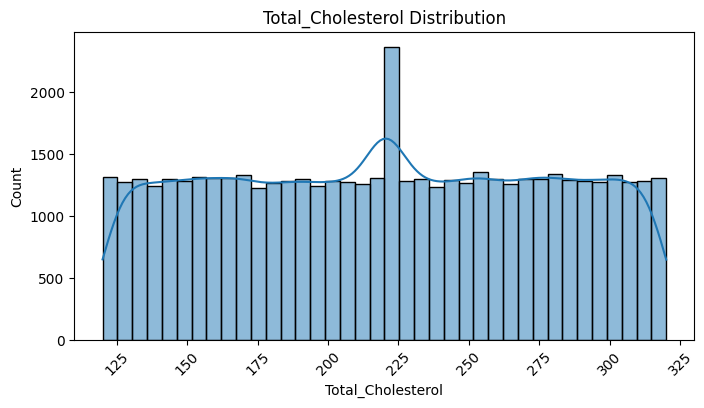

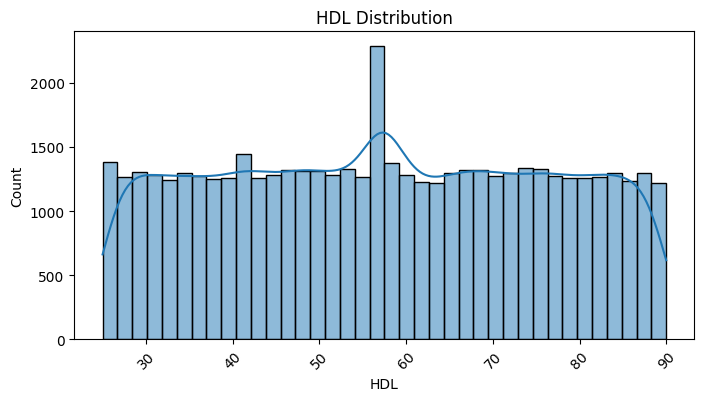

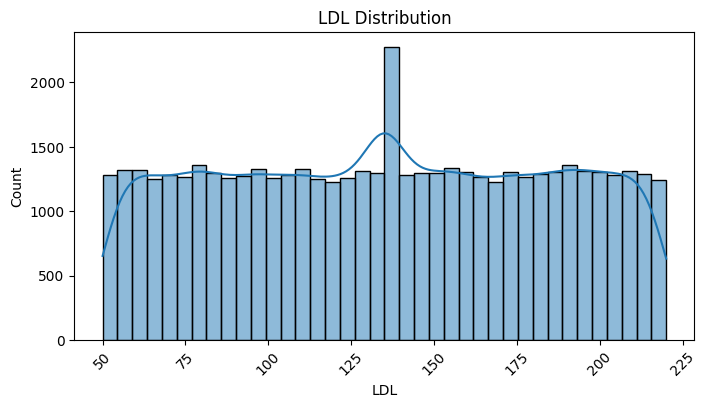

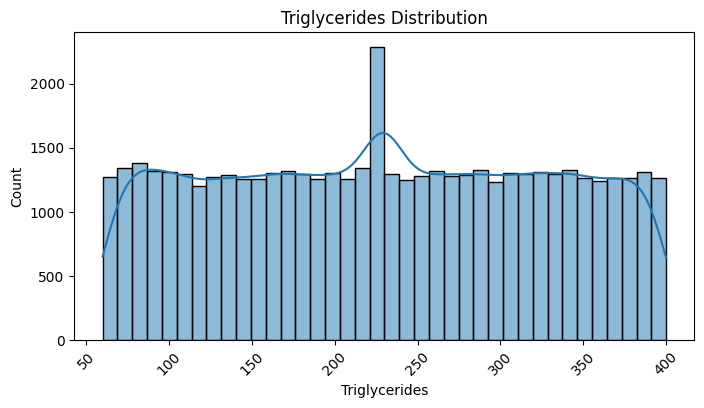

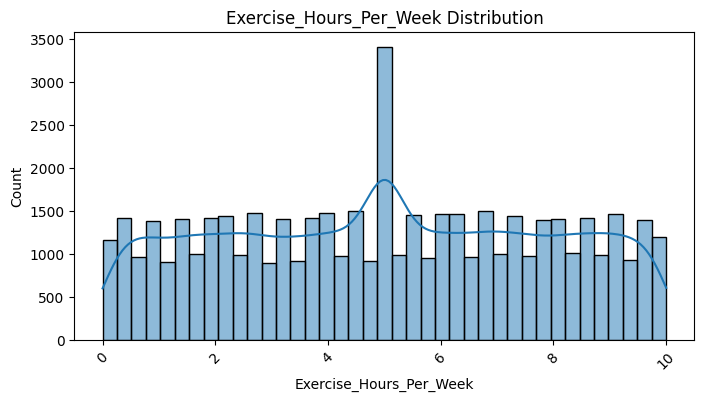

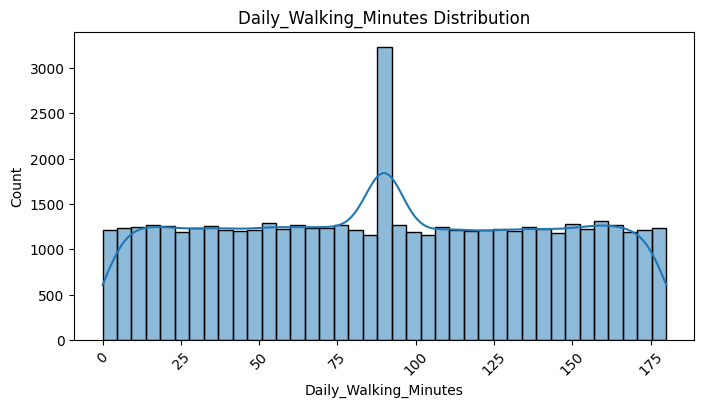

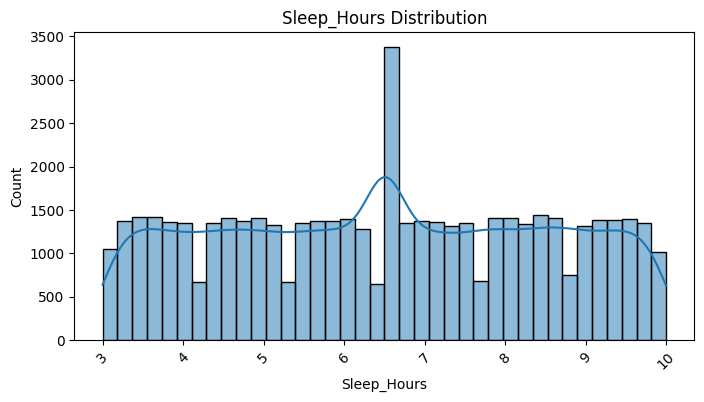

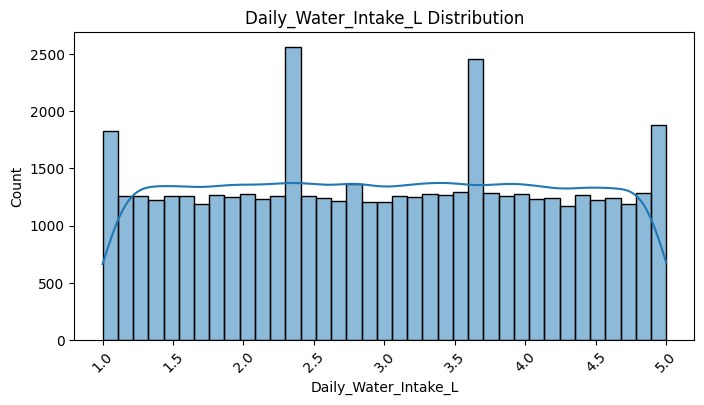

In [23]:
numerical_cols = df.select_dtypes(include='number').columns

for col in numerical_cols:
    plt.figure(figsize=(8, 4))
    sns.histplot(x=df[col],kde=True)
    plt.title(f'{col} Distribution')
    plt.xticks(rotation=45)
    plt.show() 

# outliers

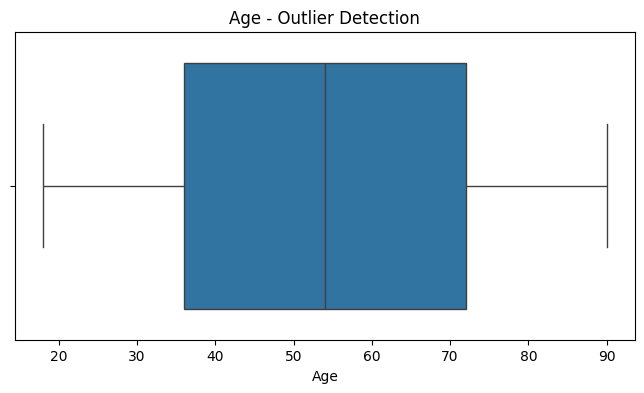

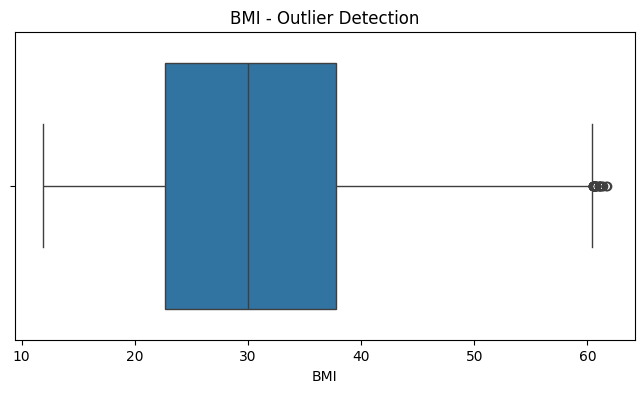

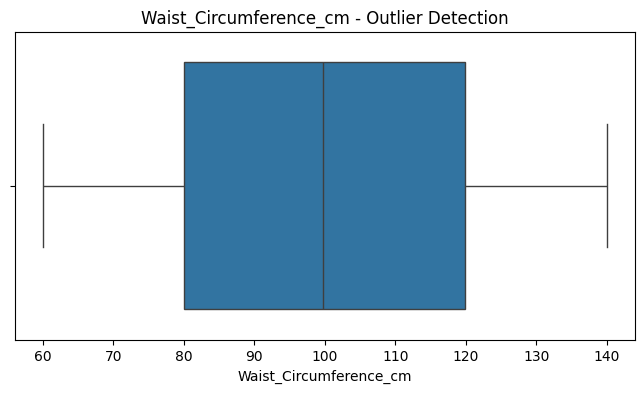

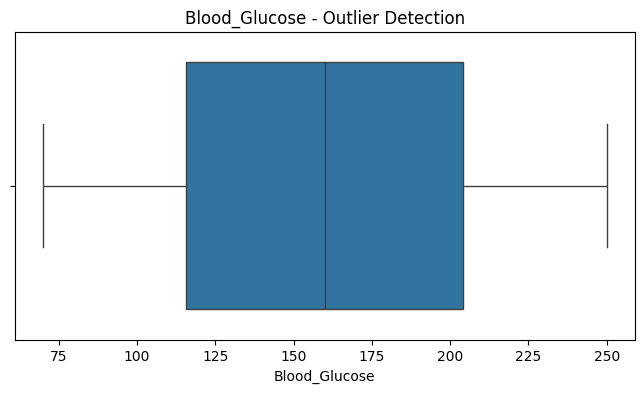

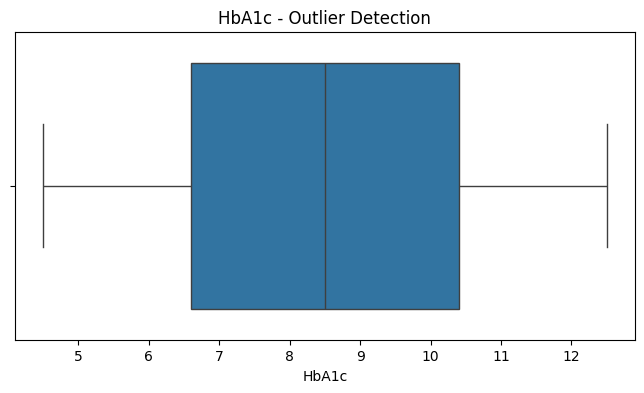

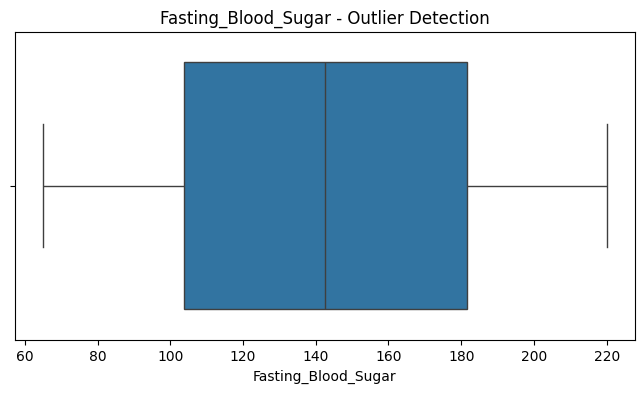

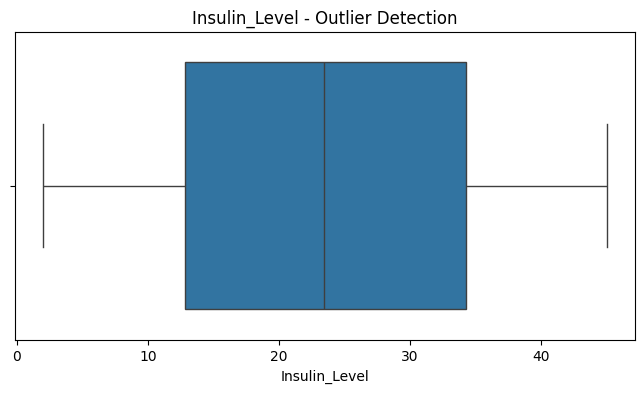

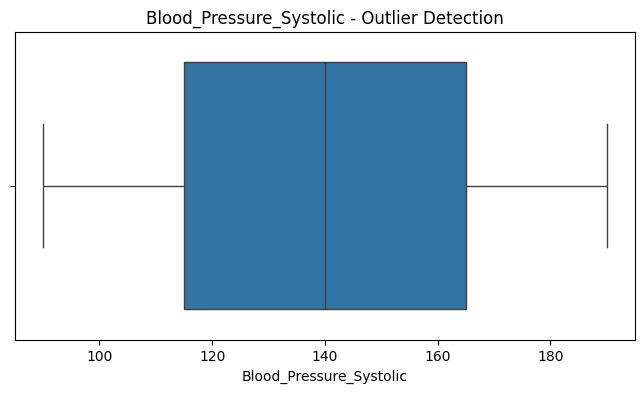

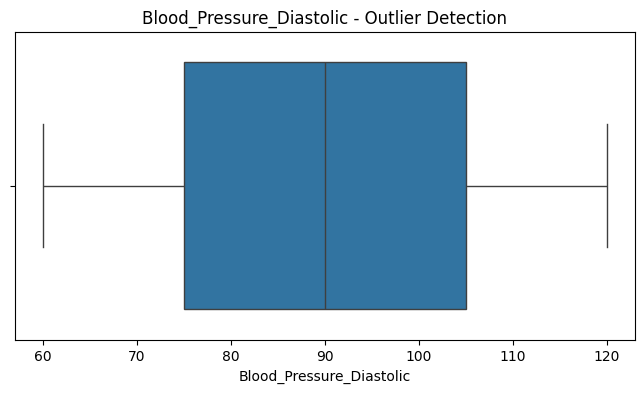

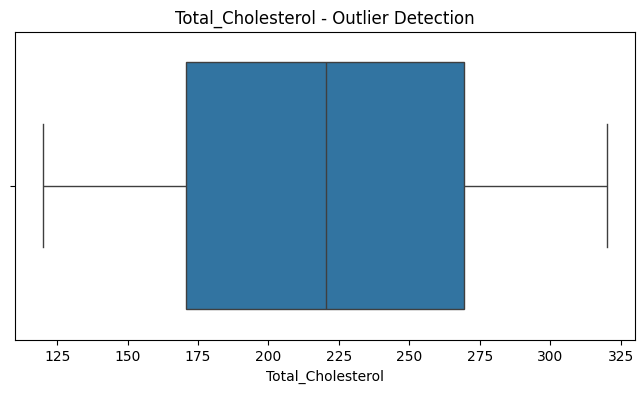

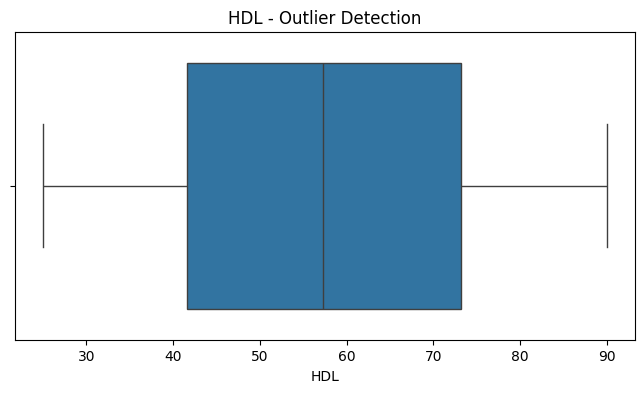

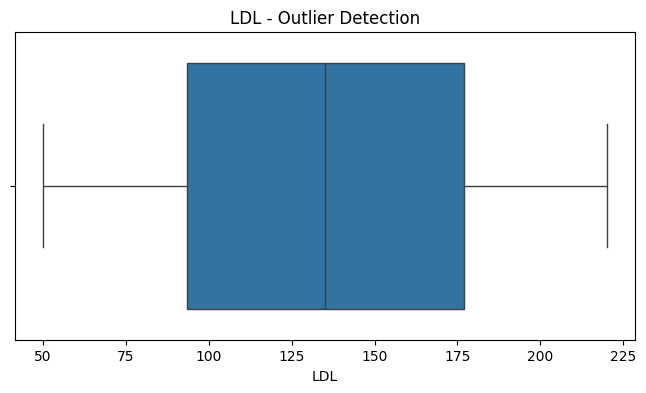

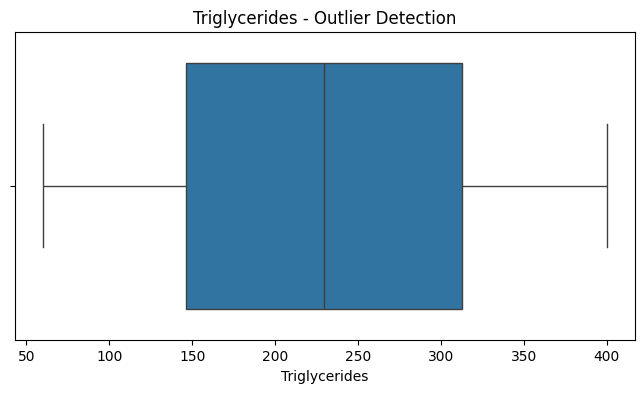

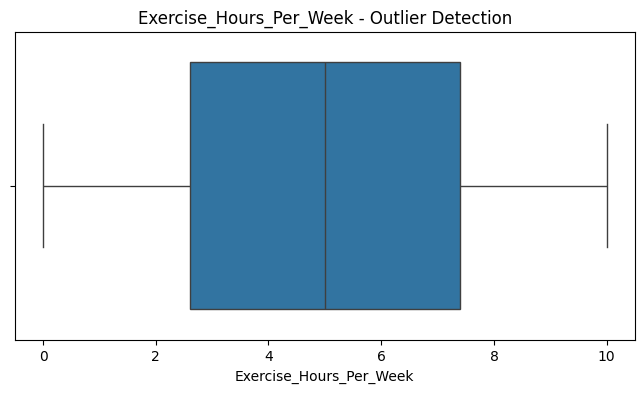

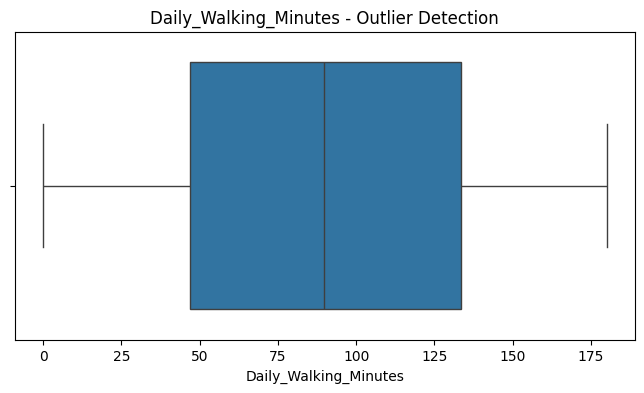

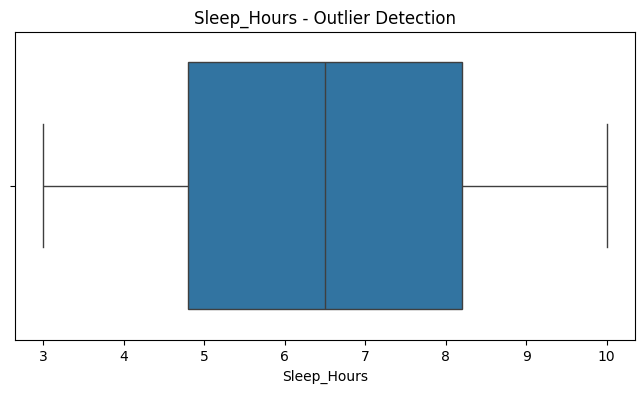

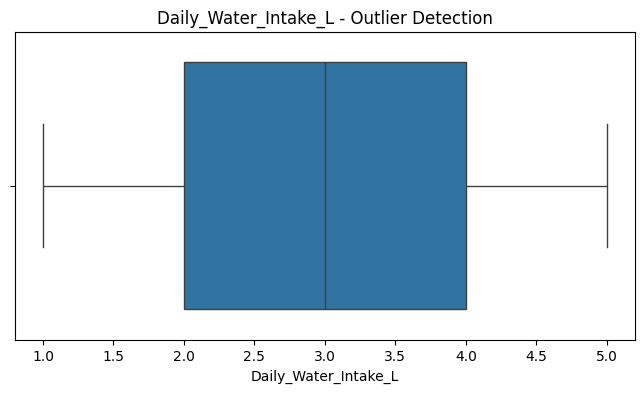

In [24]:
numerical_cols=df.select_dtypes(include='number').columns

for col in numerical_cols:
    plt.figure(figsize=(8,4))
    sns.boxplot(x=df[col])
    plt.title(f'{col} - Outlier Detection')

In [25]:
for col in numerical_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    
    IQR = Q3 - Q1
    
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    
    outliers = df[(df[col] < lower) | (df[col] > upper)]
    
    print(f'{col}: {len(outliers)} outliers')

Age: 0 outliers
BMI: 28 outliers
Waist_Circumference_cm: 0 outliers
Blood_Glucose: 0 outliers
HbA1c: 0 outliers
Fasting_Blood_Sugar: 0 outliers
Insulin_Level: 0 outliers
Blood_Pressure_Systolic: 0 outliers
Blood_Pressure_Diastolic: 0 outliers
Total_Cholesterol: 0 outliers
HDL: 0 outliers
LDL: 0 outliers
Triglycerides: 0 outliers
Exercise_Hours_Per_Week: 0 outliers
Daily_Walking_Minutes: 0 outliers
Sleep_Hours: 0 outliers
Daily_Water_Intake_L: 0 outliers


In [26]:
col = 'BMI'

Q1 = df[col].quantile(0.25)
Q3 = df[col].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

print("Lower:", lower)
print("Upper:", upper)

outliers = df[(df[col] < lower) | (df[col] > upper)]

print(outliers[['BMI']])

Lower: 0.05000000000000071
Upper: 60.449999999999996
        BMI
1303   60.5
3572   60.7
6697   60.8
8649   60.5
16957  60.6
17378  61.1
17695  60.7
19748  61.6
21077  60.7
21950  61.7
23195  60.6
23345  61.4
24223  60.8
24599  61.0
24724  60.8
25940  61.1
28948  60.6
33945  61.0
37077  60.5
39392  60.5
39748  60.5
40993  61.0
41890  60.8
43477  60.5
44691  61.3
44958  61.2
47797  60.6
47945  60.6


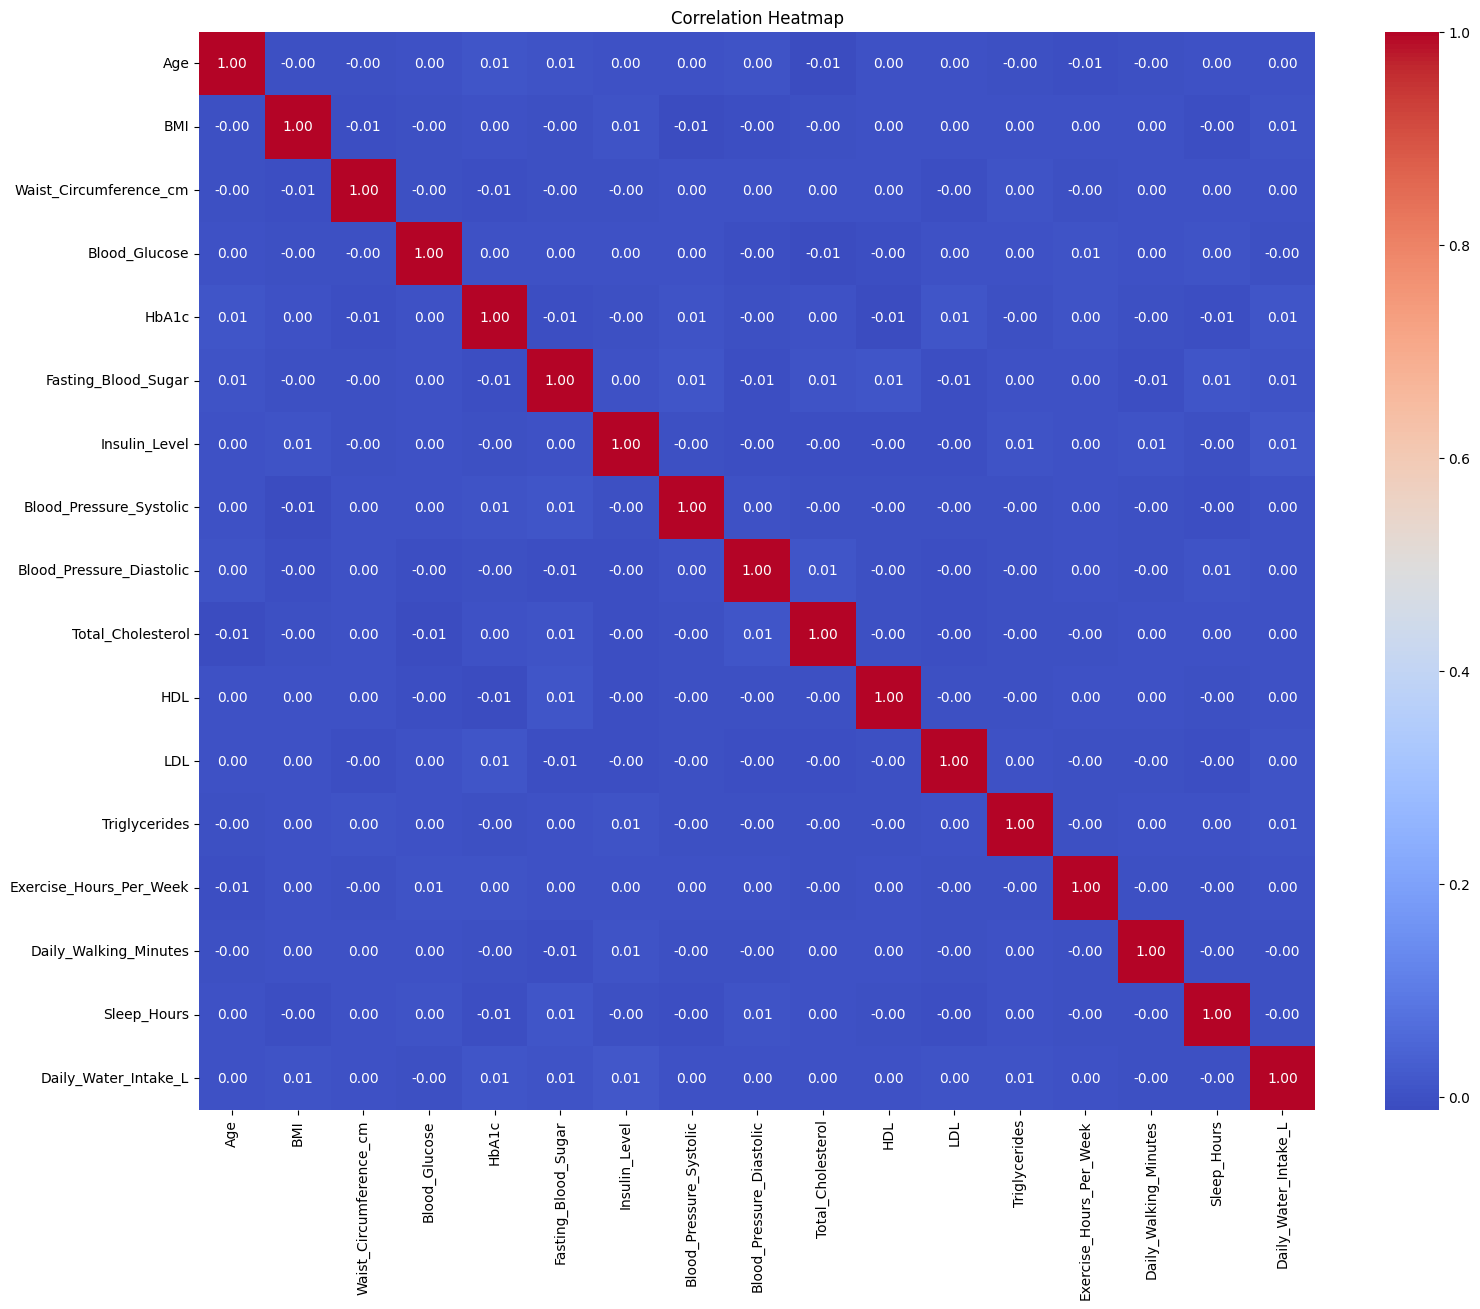

In [27]:
plt.figure(figsize=(18, 14))

sns.heatmap(
    df.corr(numeric_only=True),
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title('Correlation Heatmap')
plt.show()

# ENCODING

In [34]:
categorical_cols

Index(['Gender', 'Physical_Activity_Level', 'Diet_Quality',
       'Sugar_Intake_Level', 'Stress_Level', 'Smoking_Status',
       'Alcohol_Consumption', 'Family_History_Diabetes', 'Hypertension',
       'Heart_Disease', 'Fatty_Liver', 'PCOS', 'Work_Type', 'Residence_Type',
       'Diabetes_Risk'],
      dtype='object')

In [39]:
df_encoded = pd.get_dummies(df, columns=categorical_columns, drop_first=True,dtype=int)

In [40]:
df_encoded

,Age,BMI,Waist_Circumference_cm,Blood_Glucose,HbA1c,Fasting_Blood_Sugar,Insulin_Level,Blood_Pressure_Systolic,Blood_Pressure_Diastolic,Total_Cholesterol,...,Family_History_Diabetes_Yes,Hypertension_Yes,Heart_Disease_Yes,Fatty_Liver_Yes,PCOS_Yes,Work_Type_Government,Work_Type_Private,Work_Type_Retired,Work_Type_Student,Residence_Type_Urban
0,32.0,19.8,71.2,88.4,10.4,149.5,27.4,94,61,138.7,...,1,0,1,1,0,0,0,1,0,0
1,42.0,45.9,121.8,247.3,11.3,199.3,18.3,148,100,286.8,...,1,0,1,1,1,1,0,0,0,0
2,89.0,37.9,131.8,141.9,6.3,219.6,23.9,101,108,129.4,...,1,0,0,1,0,1,0,0,0,1
3,87.0,26.3,99.1,90.1,7.4,217.7,36.7,120,63,168.2,...,1,1,0,0,0,0,0,0,0,0
4,27.0,41.4,77.1,93.8,12.0,153.5,22.3,190,90,281.5,...,0,1,1,1,1,0,1,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
49995,52.0,45.3,75.9,248.8,9.9,191.5,15.4,97,94,193.1,...,1,0,0,0,1,0,0,1,0,1
49996,53.0,19.8,114.5,198.4,6.3,110.0,13.3,121,120,127.2,...,0,0,1,1,0,1,0,0,0,1
49997,88.0,17.4,96.1,118.8,8.5,208.4,30.5,176,119,137.6,...,1,1,0,1,1,0,0,1,0,1
49998,23.0,26.2,131.4,139.5,9.2,84.7,14.8,141,82,306.8,...,0,0,0,1,1,0,1,0,0,1


In [45]:
X=df_encoded.drop(columns=['Diabetes_Risk'])
y=df_encoded['Diabetes_Risk']

In [46]:
from sklearn.model_selection import train_test_split

In [47]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [48]:
from sklearn.preprocessing import StandardScaler
sc=StandardScaler()

In [53]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB

from sklearn.metrics import accuracy_score, classification_report


In [57]:
X_train_scaled=sc.fit_transform(X_train) 
X_test_scaled=sc.transform(X_test)

In [58]:
models={
    "Logistic Regression":LogisticRegression(max_iter=100),
    "Dicision Tree": DecisionTreeClassifier(random_state=42), 
    "Random Forest": RandomForestClassifier(n_estimators=100,random_state=42),
    "Grandient Boosting": GradientBoostingClassifier(random_state=42),
    "KNN": KNeighborsClassifier(), 
    "SVM":SVC(), 
    "Naive Bayes": GaussianNB()
}

In [59]:
results = {}

for name, model in models.items():

    # Models that benefit from scaling
    if name in ["Logistic Regression", "KNN", "SVM"]:
        model.fit(X_train_scaled, y_train)
        y_pred = model.predict(X_test_scaled)

    else:
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)

    accuracy = accuracy_score(y_test, y_pred)

    results[name] = accuracy

    print("\n==============================")
    print(name)
    print("==============================")
    print("Accuracy:", accuracy)
    print(classification_report(y_test, y_pred))


Logistic Regression
Accuracy: 0.881
              precision    recall  f1-score   support

        High       0.91      0.93      0.92      7319
         Low       0.78      0.52      0.62        94
    Moderate       0.79      0.74      0.76      2587

    accuracy                           0.88     10000
   macro avg       0.83      0.73      0.77     10000
weighted avg       0.88      0.88      0.88     10000


Dicision Tree
Accuracy: 0.8271
              precision    recall  f1-score   support

        High       0.90      0.89      0.89      7319
         Low       0.26      0.31      0.28        94
    Moderate       0.66      0.68      0.67      2587

    accuracy                           0.83     10000
   macro avg       0.61      0.62      0.61     10000
weighted avg       0.83      0.83      0.83     10000


Random Forest
Accuracy: 0.8963
              precision    recall  f1-score   support

        High       0.90      0.97      0.94      7319
         Low       1.00     

In [60]:
results_df = pd.DataFrame(
    list(results.items()),
    columns=["Model", "Accuracy"]
)

results_df = results_df.sort_values(
    by="Accuracy",
    ascending=False
)

print("\nModel Comparison:")
print(results_df)


Model Comparison:
                 Model  Accuracy
3   Grandient Boosting    0.9302
5                  SVM    0.9062
2        Random Forest    0.8963
0  Logistic Regression    0.8810
6          Naive Bayes    0.8670
1        Dicision Tree    0.8271
4                  KNN    0.7727


In [61]:
final_model = GradientBoostingClassifier(
    random_state=42
)

final_model.fit(X_train, y_train)

GradientBoostingClassifier(random_state=42)

In [62]:
y_pred = final_model.predict(X_test)

In [63]:
print("Accuracy:", accuracy_score(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Accuracy: 0.9302

Classification Report:
              precision    recall  f1-score   support

        High       0.94      0.98      0.96      7319
         Low       0.75      0.13      0.22        94
    Moderate       0.91      0.81      0.86      2587

    accuracy                           0.93     10000
   macro avg       0.86      0.64      0.68     10000
weighted avg       0.93      0.93      0.93     10000



In [69]:
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test, y_pred)
print(cm)

[[7183    0  136]
 [   0   12   82]
 [ 476    4 2107]]


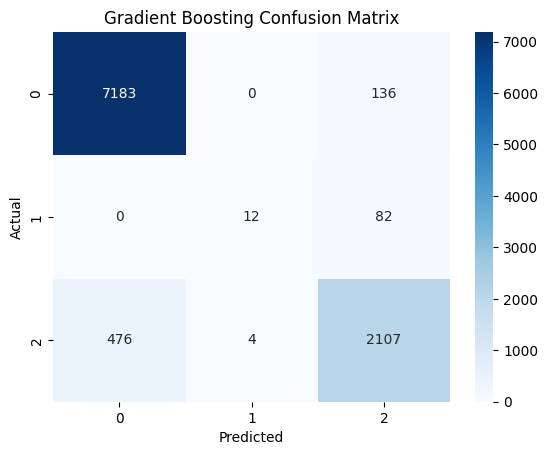

In [70]:
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Gradient Boosting Confusion Matrix")
plt.show()

In [71]:
importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': final_model.feature_importances_
})

importance = importance.sort_values(
    by='Importance',
    ascending=False
)

print(importance.head(15)) 

                        Feature  Importance
5           Fasting_Blood_Sugar    0.330769
4                         HbA1c    0.205211
31  Family_History_Diabetes_Yes    0.096277
0                           Age    0.089933
1                           BMI    0.063343
7       Blood_Pressure_Systolic    0.028700
32             Hypertension_Yes    0.028371
19  Physical_Activity_Level_Low    0.024368
22            Diet_Quality_Poor    0.024243
35                     PCOS_Yes    0.020517
33            Heart_Disease_Yes    0.020461
9             Total_Cholesterol    0.015171
8      Blood_Pressure_Diastolic    0.011209
34              Fatty_Liver_Yes    0.010281
26        Stress_Level_Moderate    0.005704


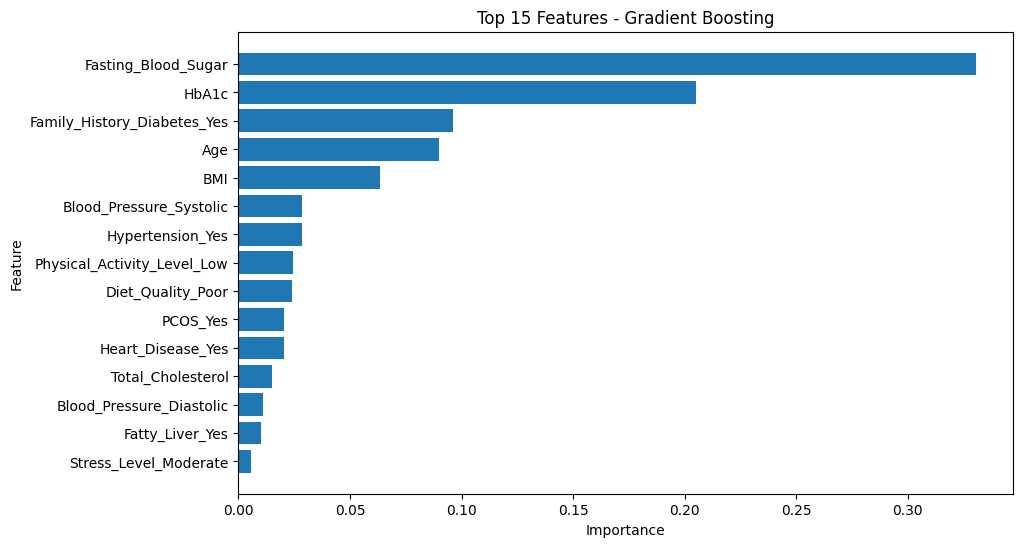

In [72]:
plt.figure(figsize=(10, 6))

plt.barh(
    importance['Feature'].head(15)[::-1],
    importance['Importance'].head(15)[::-1]
)

plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Top 15 Features - Gradient Boosting")

plt.show() 

In [73]:
import joblib

joblib.dump(final_model, "diabetes_risk_model.pkl")
joblib.dump(X.columns.tolist(), "feature_columns.pkl") 

['feature_columns.pkl']